# Delay-and-Sum Beamforming

Conventional delay-and-sum is the baseline array beamformer. It steers the array by phase-aligning a look direction and summing the sensors.

## Math

Following PySDR notation, the steering vector is $s$, the number of receive elements is $N_r$, and the received data matrix $X$ has shape $N_r \times N$.

$$
s(\theta) = e^{2j\pi d k \sin(\theta)}, \quad k = 0, 1, \ldots, N_r - 1
$$

For conventional delay-and-sum, the weights are the steering vector for the look direction:

$$
w(\theta) = s(\theta)
$$

The weighted output is:

$$
X_{weighted}(\theta) = w^H(\theta)X
$$

For DOA estimation, the look direction is swept over a range of angles and the output power is evaluated at each angle:

$$
P_{DAS}(\theta) = var(X_{weighted}(\theta))
$$

The estimated DOA corresponds to the angle producing the maximum output power.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.grid"] = True


In [2]:
def steering_vector(Nr, d, theta_deg):
    """PySDR-style ULA steering vector. d is measured in wavelengths."""
    theta = np.deg2rad(theta_deg)
    k = np.arange(Nr).reshape(-1, 1)
    s = np.exp(2j * np.pi * d * k * np.sin(theta))
    return s


def complex_noise(shape, rng, power=1.0):
    """Circular complex Gaussian noise with E{|n|^2}=power."""
    return np.sqrt(power / 2) * (
        rng.standard_normal(shape) + 1j * rng.standard_normal(shape)
    )


def simulate_snapshots(Nr, d, thetas_deg, N, source_powers=None, snr_db=20, seed=0):
    """Simulate narrowband far-field snapshots for a ULA.

    Returns X with shape Nr x N, matching the PySDR convention.
    """
    rng = np.random.default_rng(seed)
    thetas_deg = np.asarray(thetas_deg, dtype=float)
    if source_powers is None:
        source_powers = np.ones(len(thetas_deg))
    source_powers = np.asarray(source_powers, dtype=float)

    S_theta = np.hstack([steering_vector(Nr, d, theta) for theta in thetas_deg])
    signals = complex_noise((len(thetas_deg), N), rng)
    signals *= np.sqrt(source_powers).reshape(-1, 1)
    X = S_theta @ signals

    if snr_db is not None:
        signal_power = np.mean(np.abs(X) ** 2)
        noise_power = signal_power / (10 ** (snr_db / 10))
        X = X + complex_noise(X.shape, rng, noise_power)

    return X, S_theta, signals


def sample_covariance(X):
    """Estimate R = (X @ X.conj().T) / N."""
    return (X @ X.conj().T) / X.shape[1]


def to_db(power, floor_db=-80):
    power = np.asarray(power, dtype=float)
    peak = np.max(power)
    floor = peak * (10 ** (floor_db / 10))
    return 10 * np.log10(np.maximum(power, floor) / peak)


In [3]:
# Simulation parameters
Nr = 8
d = 0.5              # spacing in wavelengths
true_theta = 30      # degrees
N = 2048             # time samples
snr_db = 15

X, S_theta, signals = simulate_snapshots(
    Nr,
    d,
    [true_theta],
    N,
    snr_db=snr_db,
    seed=0,
)
R = sample_covariance(X)

print(f"Snapshot matrix shape: {X.shape}")
print(f"True DOA: {true_theta:.1f} degrees")


Snapshot matrix shape: (8, 2048)
True DOA: 30.0 degrees


Estimated DOA: 30.0 degrees


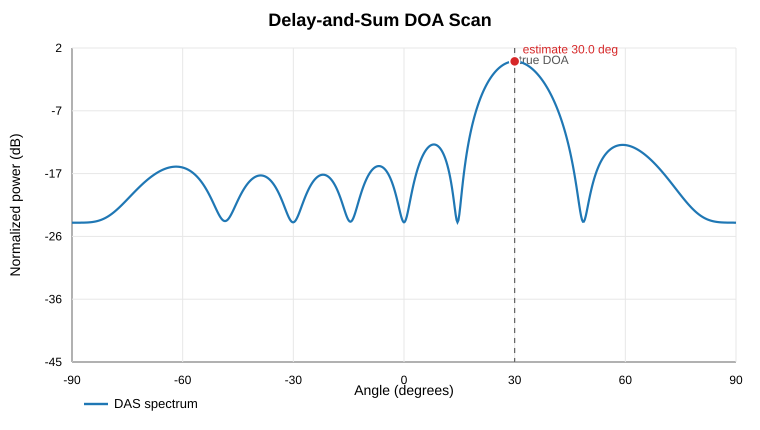

In [4]:
# Delay-and-sum scan
scan_angles = np.linspace(-90, 90, 721)
power = []

for theta in scan_angles:
    s = steering_vector(Nr, d, theta)
    w = s
    X_weighted = w.conj().T @ X
    power.append(np.var(X_weighted))

spectrum_db = to_db(power)
estimate = scan_angles[np.argmax(spectrum_db)]
print(f"Estimated DOA: {estimate:.1f} degrees")

plt.plot(scan_angles, spectrum_db)
plt.axvline(true_theta, color="k", linestyle="--", label="true DOA")
plt.plot(estimate, spectrum_db.max(), "ro", label="estimate")
plt.xlabel("Angle (degrees)")
plt.ylabel("Normalized power (dB)")
plt.title("Delay-and-Sum DOA Scan")
plt.ylim(-45, 2)
plt.legend()
plt.show()


## What to notice

The main lobe is broad because resolution is limited by array aperture. More sensors or a larger aperture narrows the lobe, while spacing above half a wavelength can introduce grating lobes.